# Exercise Analysis System — YOLOv8 Pose + EMA + Rule-Based Counting

This notebook implements the **coding part only** of the project requirements for:

- Push-up pose estimation, smoothing, repetition counting, form assessment, and JSON output.
- Squat pose estimation, smoothing, repetition counting, form assessment, and JSON output.

It uses **YOLOv8 small pose estimation model**: `yolov8s-pose.pt`.

## What you need to change before running
Upload your videos to Colab / Jupyter and edit these paths in the configuration cell:

```python
PUSHUP_VIDEO_PATH = "/content/pushups.mp4"
SQUAT_VIDEO_PATH = "/content/squats.mp4"
```

Then run all cells from top to bottom.


In [ ]:
# Install dependencies.
# In Colab, run this cell once. In a local environment, you can also install these packages in your venv.
%pip install -q ultralytics opencv-python matplotlib numpy

## 1. Configuration

The system is written so the threshold values are easy to tune for different camera angles and videos.

Counting thresholds are intentionally slightly more forgiving than the form-quality thresholds:
- A shallow squat / push-up can still be counted as a repetition.
- It is marked as bad form if it does not satisfy the stricter form rule.


In [ ]:
from pathlib import Path

# =========================
# Video paths
# =========================
PUSHUP_VIDEO_PATH = "/content/pushups.mp4"
SQUAT_VIDEO_PATH = "/content/squats.mp4"

# Output JSON path
OUTPUT_JSON_PATH = "/content/exercise_analysis_output.json"

# YOLOv8 small pose model required by the project
YOLO_MODEL_NAME = "yolov8s-pose.pt"

# Inference settings
CONF_THRESHOLD = 0.35
IOU_THRESHOLD = 0.70
FRAME_STRIDE = 1          # 1 = analyze every frame, 2 = every second frame, etc.
MAX_FRAMES = None         # Use an int for quick testing, None for full video

# Keypoint smoothing
EMA_ALPHA = 0.35
KEYPOINT_CONF_THRESHOLD = 0.25
MAX_MISSING_GAP = 8       # number of processed frames to carry previous keypoints briefly

# Rule thresholds. Adjust only if your camera angle/video requires it.
RULES = {
    "pushups": {
        # Repetition count rules
        "count_top_elbow_angle_min": 140,
        "count_bottom_elbow_angle_max": 115,

        # Good-form rules calibrated to this video
        "good_depth_elbow_angle_max": 125,
        "top_elbow_angle_min": 140,
        "body_line_angle_min": 125,   # lowered to match valid video minimum around 127.45
    },
    "squats": {
        # Repetition count rules
        "count_top_knee_angle_min": 140,
        "count_bottom_knee_angle_max": 115,

        # Good-form rules calibrated to this video
        "good_depth_knee_angle_max": 105,
        "top_knee_angle_min": 150,
        "max_left_right_knee_diff": 95,  # max observed was about 91.84
    },
}
print("Configuration ready.")

Configuration ready.


## 2. Imports and Model Loading

In [ ]:
import cv2
import json
import math
import time
import uuid
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from ultralytics import YOLO

model = YOLO(YOLO_MODEL_NAME)
print(f"Loaded model: {YOLO_MODEL_NAME}")

Loaded model: yolov8s-pose.pt


## 3. YOLOv8 Pose Keypoint Mapping

In [ ]:
# YOLOv8 pose uses the COCO 17-keypoint format.
KP = {
    "nose": 0,
    "left_eye": 1,
    "right_eye": 2,
    "left_ear": 3,
    "right_ear": 4,
    "left_shoulder": 5,
    "right_shoulder": 6,
    "left_elbow": 7,
    "right_elbow": 8,
    "left_wrist": 9,
    "right_wrist": 10,
    "left_hip": 11,
    "right_hip": 12,
    "left_knee": 13,
    "right_knee": 14,
    "left_ankle": 15,
    "right_ankle": 16,
}

print("Keypoint mapping loaded.")

Keypoint mapping loaded.


## 4. Geometry and Keypoint Utility Functions

In [ ]:
def is_valid_number(x):
    return x is not None and np.isfinite(x)


def get_point(keypoints, index, min_conf=KEYPOINT_CONF_THRESHOLD):
    """Return the 2D point of a keypoint if visible enough; otherwise None.

    YOLOv8 keypoint row format: [x, y, confidence].
    """
    if keypoints is None:
        return None
    if index < 0 or index >= len(keypoints):
        return None

    x, y, conf = keypoints[index]
    if conf < min_conf:
        return None
    if not np.isfinite(x) or not np.isfinite(y):
        return None
    return np.array([float(x), float(y)], dtype=np.float32)


def calculate_angle(p1, p2, p3):
    """Calculate the angle in degrees at p2 using points p1-p2-p3."""
    if p1 is None or p2 is None or p3 is None:
        return None

    p1 = np.asarray(p1, dtype=np.float32)
    p2 = np.asarray(p2, dtype=np.float32)
    p3 = np.asarray(p3, dtype=np.float32)

    v1 = p1 - p2
    v2 = p3 - p2

    denom = np.linalg.norm(v1) * np.linalg.norm(v2) # compute vector magnitude to turn it into a pure angle measure
    if denom < 1e-8:
        return None

    cos_angle = np.dot(v1, v2) / denom
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_angle)))


def angle_from_keypoints(keypoints, a, b, c, min_conf=KEYPOINT_CONF_THRESHOLD):
    """Calculate angle a-b-c from YOLO keypoints, centered at b."""
    p1 = get_point(keypoints, a, min_conf)
    p2 = get_point(keypoints, b, min_conf)
    p3 = get_point(keypoints, c, min_conf)
    return calculate_angle(p1, p2, p3)


def mean_valid(values):
    """Mean of valid numeric values. Returns None if no valid values exist."""
    valid = [v for v in values if is_valid_number(v)]
    if not valid:
        return None
    return float(np.mean(valid))


def min_valid(values):
    valid = [v for v in values if is_valid_number(v)]
    return float(np.min(valid)) if valid else None


def max_valid(values):
    valid = [v for v in values if is_valid_number(v)]
    return float(np.max(valid)) if valid else None

print("Utility functions ready.")

Utility functions ready.


## 5. Pose Extraction from Video

This section performs 2D pose estimation on video frames using `yolov8s-pose.pt` and stores one main person's keypoints per processed frame.

If multiple people appear in a frame, the system keeps the person with the highest YOLO detection confidence.


In [ ]:
def select_main_person(yolo_results):
    """Select the main detected person from YOLOv8 pose results.

    Returns:
        selected_keypoints: numpy array of shape (17, 3), or None
        selected_score: detection confidence, or None
    """
    if not yolo_results:
        return None, None

    result = yolo_results[0]
    if result.keypoints is None or result.keypoints.data is None:
        return None, None

    keypoints_data = result.keypoints.data
    if keypoints_data.shape[0] == 0:
        return None, None

    keypoints_np = keypoints_data.cpu().numpy()

    # Prefer box confidence if available. Fall back to average keypoint confidence.
    if result.boxes is not None and result.boxes.conf is not None and len(result.boxes.conf) > 0:
        scores = result.boxes.conf.cpu().numpy()
    else:
        scores = np.nanmean(keypoints_np[:, :, 2], axis=1)

    selected_idx = int(np.nanargmax(scores))
    return keypoints_np[selected_idx], float(scores[selected_idx])


def extract_pose_from_video(
    video_path,
    model,
    conf_threshold=CONF_THRESHOLD,
    iou_threshold=IOU_THRESHOLD,
    frame_stride=FRAME_STRIDE,
    max_frames=MAX_FRAMES,
):
    """Run YOLOv8 pose estimation on a video and return per-frame keypoints."""
    video_path = str(video_path)
    path = Path(video_path)
    if not path.exists():
        raise FileNotFoundError(
            f"Video file not found: {video_path}\n"
            "Upload the file, then update PUSHUP_VIDEO_PATH and SQUAT_VIDEO_PATH in the config cell."
        )

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames_reported = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    keypoints_per_frame = []
    detection_scores = []
    original_frame_numbers = []

    read_frame_idx = 0
    processed_frames = 0
    start_time = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if read_frame_idx % frame_stride != 0:
            read_frame_idx += 1
            continue

        results = model.predict(
            frame,
            conf=conf_threshold,
            iou=iou_threshold,
            verbose=False,
        )

        person_keypoints, score = select_main_person(results)
        keypoints_per_frame.append(person_keypoints)
        detection_scores.append(score)
        original_frame_numbers.append(read_frame_idx)

        processed_frames += 1
        read_frame_idx += 1

        if max_frames is not None and processed_frames >= max_frames:
            break

    cap.release()
    elapsed = time.time() - start_time

    metadata = {
        "video_path": video_path,
        "fps": float(fps) if fps and fps > 0 else None,
        "width": width,
        "height": height,
        "reported_total_frames": total_frames_reported,
        "processed_frames": processed_frames,
        "frame_stride": frame_stride,
        "original_frame_numbers": original_frame_numbers,
        "inference_seconds": round(elapsed, 3),
        "frames_with_person": int(sum(kp is not None for kp in keypoints_per_frame)),
    }

    return keypoints_per_frame, detection_scores, metadata

print("Pose extraction functions ready.")

Pose extraction functions ready.


## 6. Temporal Smoothing with Exponential Moving Average

EMA reduces noise/jitter in the detected keypoints:

\[
S_t = lpha X_t + (1 - lpha) S_{t-1}
\]

where `X_t` is the current keypoint coordinate and `S_t` is the smoothed coordinate.


In [ ]:
def apply_ema_smoothing(
    keypoints_per_frame,
    alpha=EMA_ALPHA,
    min_conf=KEYPOINT_CONF_THRESHOLD,
    max_missing_gap=MAX_MISSING_GAP,
):
    """Apply EMA smoothing to YOLO keypoints over time.

    The function also carries previous coordinates for a short gap when a keypoint/person is missing.
    This makes angle series less jittery, while confidence decays so long missing segments are not trusted.
    """
    smoothed = []
    previous = None
    missing_person_gap = 0

    for current in keypoints_per_frame:
        if current is None:
            missing_person_gap += 1
            if previous is not None and missing_person_gap <= max_missing_gap:
                carried = previous.copy()
                carried[:, 2] = carried[:, 2] * 0.85
                smoothed.append(carried)
            else:
                smoothed.append(None)
            continue

        current = current.astype(np.float32).copy()

        if previous is None:
            # First valid frame.
            previous = current.copy()
            smoothed.append(previous.copy())
            missing_person_gap = 0
            continue

        output = previous.copy()
        for j in range(current.shape[0]):
            x, y, conf = current[j]
            prev_conf = previous[j, 2]

            current_valid = conf >= min_conf and np.isfinite(x) and np.isfinite(y)
            previous_valid = prev_conf >= min_conf and np.all(np.isfinite(previous[j, :2]))

            if current_valid and previous_valid:
                output[j, :2] = alpha * current[j, :2] + (1 - alpha) * previous[j, :2]
                output[j, 2] = conf
            elif current_valid and not previous_valid:
                output[j] = current[j]
            elif not current_valid and previous_valid:
                # Carry previous keypoint briefly but decay confidence.
                output[j, :2] = previous[j, :2]
                output[j, 2] = prev_conf * 0.90
            else:
                output[j, :2] = np.nan
                output[j, 2] = 0.0

        previous = output.copy()
        smoothed.append(output)
        missing_person_gap = 0

    return smoothed

print("EMA smoothing function ready.")

EMA smoothing function ready.


## 7. Exercise-Specific Angle Extraction

Required form logic:

### Push-ups
- Repetition counting uses average elbow angle.
- Good-form checks use:
  - elbow depth
  - body line angle: shoulder → hip → ankle

### Squats
- Repetition counting uses average knee angle.
- Good-form checks use:
  - squat depth by knee angle
  - left/right knee symmetry when both sides are visible


In [ ]:
def extract_pushup_metrics(keypoints):
    """Extract per-frame push-up metrics from smoothed keypoints."""
    left_elbow = angle_from_keypoints(
        keypoints,
        KP["left_shoulder"], KP["left_elbow"], KP["left_wrist"],
    )
    right_elbow = angle_from_keypoints(
        keypoints,
        KP["right_shoulder"], KP["right_elbow"], KP["right_wrist"],
    )
    main_elbow_angle = mean_valid([left_elbow, right_elbow])

    # Body line: if body is straight, shoulder-hip-ankle angle is close to 180 degrees.
    left_body_line = angle_from_keypoints(
        keypoints,
        KP["left_shoulder"], KP["left_hip"], KP["left_ankle"],
    )
    right_body_line = angle_from_keypoints(
        keypoints,
        KP["right_shoulder"], KP["right_hip"], KP["right_ankle"],
    )
    body_line_angle = mean_valid([left_body_line, right_body_line])

    return {
        "main_angle": main_elbow_angle,
        "left_elbow_angle": left_elbow,
        "right_elbow_angle": right_elbow,
        "body_line_angle": body_line_angle,
    }


def extract_squat_metrics(keypoints):
    """Extract per-frame squat metrics from smoothed keypoints."""
    left_knee = angle_from_keypoints(
        keypoints,
        KP["left_hip"], KP["left_knee"], KP["left_ankle"],
    )
    right_knee = angle_from_keypoints(
        keypoints,
        KP["right_hip"], KP["right_knee"], KP["right_ankle"],
    )
    main_knee_angle = mean_valid([left_knee, right_knee])

    knee_diff = None
    if is_valid_number(left_knee) and is_valid_number(right_knee):
        knee_diff = abs(left_knee - right_knee)

    return {
        "main_angle": main_knee_angle,
        "left_knee_angle": left_knee,
        "right_knee_angle": right_knee,
        "left_right_knee_diff": knee_diff,
    }


def build_metrics(smoothed_keypoints, exercise_type):
    """Build per-frame metric dictionaries and the main angle series."""
    if exercise_type == "pushups":
        metric_fn = extract_pushup_metrics
    elif exercise_type == "squats":
        metric_fn = extract_squat_metrics
    else:
        raise ValueError("exercise_type must be 'pushups' or 'squats'")

    metrics = []
    main_angles = []

    for keypoints in smoothed_keypoints:
        if keypoints is None:
            metric = {"main_angle": None}
        else:
            metric = metric_fn(keypoints)
        metrics.append(metric)
        main_angles.append(metric.get("main_angle"))

    return metrics, main_angles

print("Exercise metric functions ready.")

Exercise metric functions ready.


## 8. Repetition Counting State Machine

The state machine counts one repetition when the movement goes:

`TOP / EXTENDED → BOTTOM / FLEXED → TOP / EXTENDED`

This prevents counting every noisy threshold crossing as a rep.


In [ ]:
def detect_reps(
    angles,
    top_threshold,
    bottom_threshold,
    min_rep_frames=6, #Minimum number of processed frames required for a valid repetition
    max_missing_inside_rep=15, #Maximum allowed consecutive invalid/missing frames during a rep
):
    """Detect repetitions from an angle series using a TOP -> BOTTOM -> TOP state machine."""
    reps = []
    state = "WAIT_FOR_TOP"
    start_frame = None
    bottom_frame = None
    rep_angles = []
    missing_count = 0

    for frame_idx, angle in enumerate(angles): #loop through a collection while also getting the index (position) of each item
        if not is_valid_number(angle):
            if state != "WAIT_FOR_TOP":
                missing_count += 1
                if missing_count > max_missing_inside_rep:
                    state = "WAIT_FOR_TOP"
                    start_frame = None
                    bottom_frame = None
                    rep_angles = []
                    missing_count = 0
            continue

        missing_count = 0

        if state == "WAIT_FOR_TOP":
            if angle >= top_threshold:
                state = "TOP"
                start_frame = frame_idx
                bottom_frame = None
                rep_angles = [angle]

        elif state == "TOP":
            rep_angles.append(angle)
            if angle <= bottom_threshold:
                state = "BOTTOM"
                bottom_frame = frame_idx

        elif state == "BOTTOM":
            rep_angles.append(angle)
            if angle >= top_threshold:
                duration = frame_idx - start_frame if start_frame is not None else 0
                if start_frame is not None and bottom_frame is not None and duration >= min_rep_frames:
                    reps.append({
                        "rep_number": len(reps) + 1,
                        "start_frame": int(start_frame),
                        "bottom_frame": int(bottom_frame),
                        "end_frame": int(frame_idx),
                        "min_angle": round(float(np.min(rep_angles)), 2),
                        "max_angle": round(float(np.max(rep_angles)), 2),
                        "duration_processed_frames": int(duration),
                    })

                # Current frame is already top position, so it can start the next repetition.
                state = "TOP"
                start_frame = frame_idx
                bottom_frame = None
                rep_angles = [angle]

    return reps

print("Repetition counting state machine ready.")

Repetition counting state machine ready.


## 9. Form Assessment Per Repetition

This section marks each counted repetition as good or bad form.

A repetition can be counted but still be bad form if it does not satisfy the validation rule.


In [ ]:
def values_in_rep(metrics, start, end, key): #start and end frame, extract value of one specific metric
    return [m.get(key) for m in metrics[start:end + 1] if is_valid_number(m.get(key))]


def assess_pushup_reps(reps, metrics, rules):
    """Add push-up form assessment to every detected repetition."""
    assessed = []

    for rep in reps:
        start = rep["start_frame"]
        end = rep["end_frame"]

        elbow_angles = values_in_rep(metrics, start, end, "main_angle")
        body_line_angles = values_in_rep(metrics, start, end, "body_line_angle")

        min_elbow = min_valid(elbow_angles)
        max_elbow = max_valid(elbow_angles)
        min_body_line = min_valid(body_line_angles)

        elbow_depth_ok = (min_elbow is not None) and (min_elbow <= rules["good_depth_elbow_angle_max"])
        top_extension_ok = (max_elbow is not None) and (max_elbow >= rules["top_elbow_angle_min"])
        body_line_ok = (min_body_line is not None) and (min_body_line >= rules["body_line_angle_min"])

        good_form = bool(elbow_depth_ok and top_extension_ok and body_line_ok)

        rep_assessment = dict(rep)
        rep_assessment.update({
            "good_form": good_form,
            "form_checks": {
                "elbow_depth_ok": bool(elbow_depth_ok),
                "top_extension_ok": bool(top_extension_ok),
                "body_line_ok": bool(body_line_ok),
                "min_elbow_angle": round(min_elbow, 2) if min_elbow is not None else None,
                "max_elbow_angle": round(max_elbow, 2) if max_elbow is not None else None,
                "min_body_line_angle": round(min_body_line, 2) if min_body_line is not None else None,
                "rules": {
                    "good_depth_elbow_angle_max": rules["good_depth_elbow_angle_max"],
                    "top_elbow_angle_min": rules["top_elbow_angle_min"],
                    "body_line_angle_min": rules["body_line_angle_min"],
                },
            },
        })
        assessed.append(rep_assessment)

    return assessed


def assess_squat_reps(reps, metrics, rules):
    """Add squat form assessment to every detected repetition."""
    assessed = []

    for rep in reps:
        start = rep["start_frame"]
        end = rep["end_frame"]

        knee_angles = values_in_rep(metrics, start, end, "main_angle")
        knee_diffs = values_in_rep(metrics, start, end, "left_right_knee_diff")

        min_knee = min_valid(knee_angles)
        max_knee = max_valid(knee_angles)
        max_knee_diff = max_valid(knee_diffs)

        depth_ok = (min_knee is not None) and (min_knee <= rules["good_depth_knee_angle_max"])
        top_extension_ok = (max_knee is not None) and (max_knee >= rules["top_knee_angle_min"])

        # If both knees are visible, check symmetry. If one side is not visible, do not fail the rep only for symmetry.
        symmetry_ok = None
        if max_knee_diff is not None:
            symmetry_ok = max_knee_diff <= rules["max_left_right_knee_diff"]

        good_form = bool(depth_ok and top_extension_ok and (symmetry_ok is not False))

        rep_assessment = dict(rep)
        rep_assessment.update({
            "good_form": good_form,
            "form_checks": {
                "squat_depth_ok": bool(depth_ok),
                "top_extension_ok": bool(top_extension_ok),
                "knee_symmetry_ok": symmetry_ok,
                "min_knee_angle": round(min_knee, 2) if min_knee is not None else None,
                "max_knee_angle": round(max_knee, 2) if max_knee is not None else None,
                "max_left_right_knee_diff": round(max_knee_diff, 2) if max_knee_diff is not None else None,
                "rules": {
                    "good_depth_knee_angle_max": rules["good_depth_knee_angle_max"],
                    "top_knee_angle_min": rules["top_knee_angle_min"],
                    "max_left_right_knee_diff": rules["max_left_right_knee_diff"],
                },
            },
        })
        assessed.append(rep_assessment)

    return assessed

print("Form assessment functions ready.")

Form assessment functions ready.


## 10. Full Exercise Analyzer

This integrates all required coding components:

1. Pose estimation
2. EMA smoothing
3. Repetition counting
4. Joint-angle form assessment
5. Structured JSON-ready result


In [ ]:
def angle_stats(angles):
    valid = [a for a in angles if is_valid_number(a)]
    if not valid:
        return {
            "valid_frames": 0,
            "min": None,
            "max": None,
            "mean": None,
        }
    return {
        "valid_frames": int(len(valid)),
        "min": round(float(np.min(valid)), 2),
        "max": round(float(np.max(valid)), 2),
        "mean": round(float(np.mean(valid)), 2),
    }


def analyze_exercise_video(video_path, exercise_type, model):
    """Analyze one exercise video and return a structured dictionary."""
    if exercise_type not in {"pushups", "squats"}:
        raise ValueError("exercise_type must be 'pushups' or 'squats'")

    print(f"\n========== Analyzing {exercise_type.upper()} ==========")
    print(f"Video: {video_path}")

    raw_keypoints, detection_scores, metadata = extract_pose_from_video(video_path, model)
    smoothed_keypoints = apply_ema_smoothing(raw_keypoints)
    metrics, main_angles = build_metrics(smoothed_keypoints, exercise_type)

    fps = metadata.get("fps") or 30.0
    processed_fps = fps / max(FRAME_STRIDE, 1) #Calculate Processed FPS
    min_rep_frames = max(4, int(processed_fps * 0.25)) #How many processed frames should the shortest valid rep last

    rules = RULES[exercise_type]

    if exercise_type == "pushups":
        reps = detect_reps(
            main_angles,
            top_threshold=rules["count_top_elbow_angle_min"],
            bottom_threshold=rules["count_bottom_elbow_angle_max"],
            min_rep_frames=min_rep_frames,
        )
        assessed_reps = assess_pushup_reps(reps, metrics, rules)
        angle_name = "average_elbow_angle"
    else:
        reps = detect_reps(
            main_angles,
            top_threshold=rules["count_top_knee_angle_min"],
            bottom_threshold=rules["count_bottom_knee_angle_max"],
            min_rep_frames=min_rep_frames,
        )
        assessed_reps = assess_squat_reps(reps, metrics, rules)
        angle_name = "average_knee_angle"

    total_reps = len(assessed_reps)
    good_form_reps = sum(1 for r in assessed_reps if r["good_form"])

    result = {
        "exercise_type": exercise_type,
        "video_path": str(video_path),
        "metadata": metadata,
        "model": YOLO_MODEL_NAME,
        "smoothing": {
            "method": "EMA",
            "alpha": EMA_ALPHA,
            "keypoint_conf_threshold": KEYPOINT_CONF_THRESHOLD,
        },
        "counting": {
            "angle_used": angle_name,
            "min_rep_frames": min_rep_frames,
        },
        "angle_stats": angle_stats(main_angles),
        "total_reps": int(total_reps),
        "good_form_reps": int(good_form_reps),
        "bad_form_reps": int(total_reps - good_form_reps),
        "reps": assessed_reps,
        # Kept for plotting/debugging inside notebook. Removed from final JSON by default.
        "_debug_main_angles": main_angles,
        "_debug_metrics": metrics,
    }

    print(f"Frames processed: {metadata['processed_frames']}")
    print(f"Frames with person: {metadata['frames_with_person']}")
    print(f"Total reps: {total_reps}")
    print(f"Good-form reps: {good_form_reps}")

    return result

print("Full analyzer function ready.")

Full analyzer function ready.


## 11. Run Push-up and Squat Analysis

In [ ]:
pushup_result = analyze_exercise_video(PUSHUP_VIDEO_PATH, "pushups", model)
squat_result = analyze_exercise_video(SQUAT_VIDEO_PATH, "squats", model)

print("\nAnalysis completed.")


========== Analyzing PUSHUPS ==========
Video: /content/pushups.mp4
Frames processed: 252
Frames with person: 252
Total reps: 10
Good-form reps: 5

========== Analyzing SQUATS ==========
Video: /content/squats.mp4
Frames processed: 571
Frames with person: 451
Total reps: 10
Good-form reps: 10

Analysis completed.


## 12. Visualize Angle Series and Counted Repetitions

The shaded areas represent counted repetitions. Use these plots to tune thresholds if needed.



PUSHUPS DEBUG ANALYSIS
Total reps      : 10
Good form reps  : 0
Bad form reps   : 10

Active thresholds:
  count_top_elbow_angle_min: 140
  count_bottom_elbow_angle_max: 115
  good_depth_elbow_angle_max: 125
  top_elbow_angle_min: 140
  body_line_angle_min: 125

Per-rep debug table:


,rep,status,start,bottom,end,min_angle,max_angle,elbow_depth_ok,top_extension_ok,body_line_ok,min_elbow_angle,max_elbow_angle,min_body_line_angle
0,1,BAD,5,16,31,48.48,153.78,True,True,False,48.48,153.78,NaN
1,2,BAD,31,41,54,57.27,152.10,True,True,False,57.27,152.10,NaN
2,3,GOOD,54,65,79,53.72,153.28,True,True,True,53.72,153.28,163.51
3,4,GOOD,79,89,102,47.97,154.44,True,True,True,47.97,154.44,127.45
4,5,GOOD,102,113,128,54.63,156.23,True,True,True,54.63,156.23,144.41
5,6,BAD,128,138,152,49.97,152.29,True,True,False,49.97,152.29,NaN
6,7,BAD,152,161,174,64.63,150.82,True,True,False,64.63,150.82,NaN
7,8,BAD,174,184,196,54.71,152.21,True,True,False,54.71,152.21,NaN
8,9,GOOD,196,207,220,55.24,155.19,True,True,True,55.24,155.19,140.28
9,10,GOOD,220,230,242,51.68,154.64,True,True,True,51.68,154.64,154.40



Failed check counts:
  body_line_ok: 5/10

Numeric ranges:
  min_elbow_angle: min=47.97, median=54.18, max=64.63
  max_elbow_angle: min=150.82, median=153.53, max=156.23
  min_body_line_angle: min=127.45, median=144.41, max=163.51


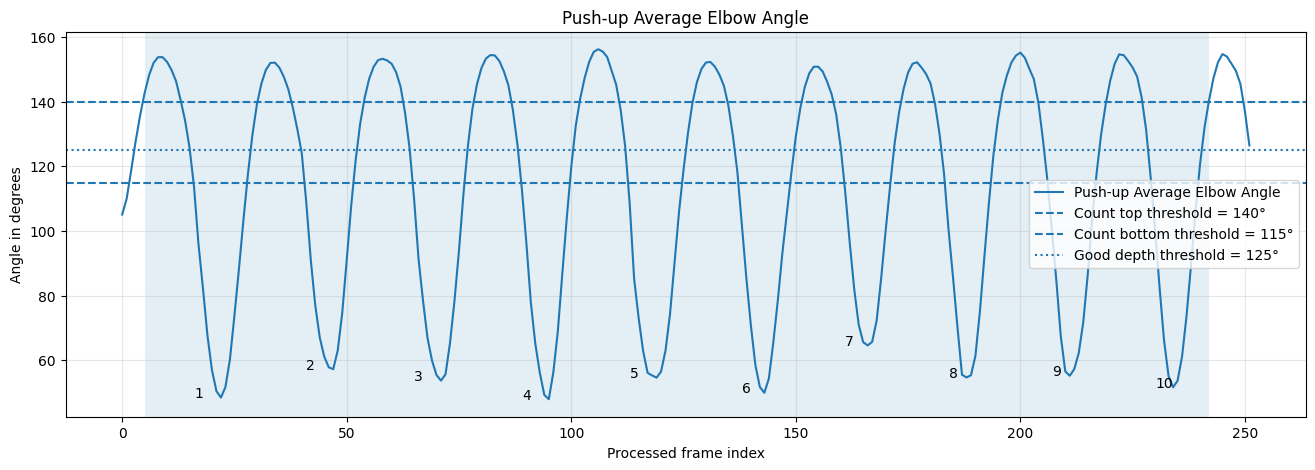


SQUATS DEBUG ANALYSIS
Total reps      : 10
Good form reps  : 0
Bad form reps   : 10

Active thresholds:
  count_top_knee_angle_min: 140
  count_bottom_knee_angle_max: 115
  good_depth_knee_angle_max: 105
  top_knee_angle_min: 150
  max_left_right_knee_diff: 95

Per-rep debug table:


,rep,status,start,bottom,end,min_angle,max_angle,squat_depth_ok,top_extension_ok,knee_symmetry_ok,min_knee_angle,max_knee_angle,max_left_right_knee_diff
0,1,GOOD,0,9,26,26.58,158.86,True,True,True,26.58,158.86,75.56
1,2,GOOD,26,57,73,25.02,173.51,True,True,True,25.02,173.51,73.06
2,3,GOOD,73,103,119,22.02,175.59,True,True,True,22.02,175.59,71.71
3,4,GOOD,119,149,164,23.79,174.89,True,True,True,23.79,174.89,73.10
4,5,GOOD,164,195,211,20.04,174.49,True,True,True,20.04,174.49,76.11
5,6,GOOD,211,242,257,25.46,175.09,True,True,True,25.46,175.09,76.99
6,7,GOOD,257,290,305,26.33,174.94,True,True,True,26.33,174.94,72.82
7,8,GOOD,305,339,353,25.65,173.68,True,True,True,25.65,173.68,75.99
8,9,GOOD,353,385,400,22.72,173.68,True,True,True,22.72,173.68,84.14
9,10,GOOD,400,436,448,20.93,176.48,True,True,True,20.93,176.48,91.84



Failed check counts:
  No failed checks.

Numeric ranges:
  min_knee_angle: min=20.04, median=24.41, max=26.58
  max_knee_angle: min=158.86, median=174.69, max=176.48
  max_left_right_knee_diff: min=71.71, median=75.77, max=91.84


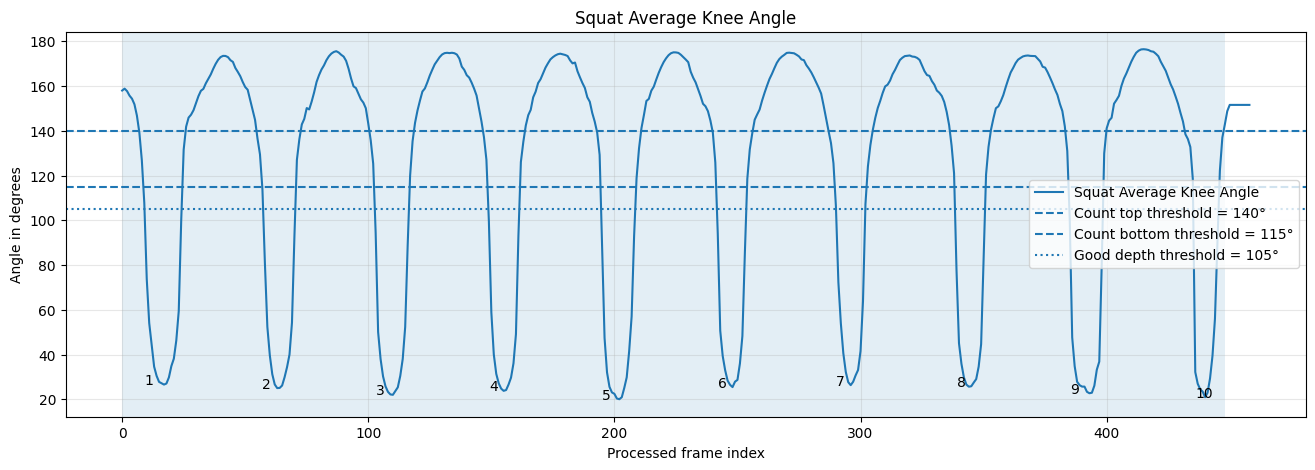

In [ ]:
import pandas as pd

def plot_exercise_angles(result):
    exercise_type = result["exercise_type"]
    angles = result["_debug_main_angles"]
    reps = result["reps"]
    rules = RULES[exercise_type]

    if exercise_type == "pushups":
        title = "Push-up Average Elbow Angle"
        top_threshold = rules["count_top_elbow_angle_min"]
        bottom_threshold = rules["count_bottom_elbow_angle_max"]
        good_depth_threshold = rules["good_depth_elbow_angle_max"]

        numeric_fields = [
            "min_elbow_angle",
            "max_elbow_angle",
            "min_body_line_angle",
        ]

    else:
        title = "Squat Average Knee Angle"
        top_threshold = rules["count_top_knee_angle_min"]
        bottom_threshold = rules["count_bottom_knee_angle_max"]
        good_depth_threshold = rules["good_depth_knee_angle_max"]

        numeric_fields = [
            "min_knee_angle",
            "max_knee_angle",
            "max_left_right_knee_diff",
        ]

    # =========================
    # Print debug values
    # =========================
    print("\n" + "=" * 100)
    print(f"{exercise_type.upper()} DEBUG ANALYSIS")
    print("=" * 100)

    total_reps = len(reps)
    good_reps = sum(1 for rep in reps if rep.get("is_good_form", False))
    bad_reps = total_reps - good_reps

    print(f"Total reps      : {total_reps}")
    print(f"Good form reps  : {good_reps}")
    print(f"Bad form reps   : {bad_reps}")

    print("\nActive thresholds:")
    for key, value in rules.items():
        print(f"  {key}: {value}")

    rows = []
    failure_counts = {}

    for rep in reps:
        # Original code used `rep.get("checks", {})` which is incorrect. `form_checks` is the correct key.
        # Also, the `is_good_form` key is `good_form` in the actual data.
        form_checks = rep.get("form_checks", {})

        row = {
            "rep": rep.get("rep_number"),
            "status": "GOOD" if rep.get("good_form", False) else "BAD",
            "start": rep.get("start_frame"),
            "bottom": rep.get("bottom_frame"),
            "end": rep.get("end_frame"),
            "min_angle": rep.get("min_angle"),
            "max_angle": rep.get("max_angle"),
        }

        # Add all check booleans and numeric values
        for key, value in form_checks.items(): # Use form_checks here
            if key == "rules":
                continue

            row[key] = value

            if key.endswith("_ok") and value is False:
                failure_counts[key] = failure_counts.get(key, 0) + 1

        rows.append(row)

    df_debug = pd.DataFrame(rows)

    print("\nPer-rep debug table:")
    display(df_debug)

    print("\nFailed check counts:")
    if failure_counts:
        for key, count in sorted(failure_counts.items(), key=lambda x: x[1], reverse=True):
            print(f"  {key}: {count}/{total_reps}")
    else:
        print("  No failed checks.")

    print("\nNumeric ranges:")
    for field in numeric_fields:
        values = []

        for rep in reps:
            # Original code used `rep.get("checks", {})` which is incorrect. `form_checks` is the correct key.
            form_checks = rep.get("form_checks", {})
            value = form_checks.get(field)

            if is_valid_number(value):
                values.append(float(value))

        if len(values) == 0:
            print(f"  {field}: no valid values")
        else:
            values = np.array(values, dtype=np.float32)
            print(
                f"  {field}: "
                f"min={np.min(values):.2f}, "
                f"median={np.median(values):.2f}, "
                f"max={np.max(values):.2f}"
            )

    # =========================
    # Angle plot
    # =========================
    x = np.arange(len(angles))
    y = np.array([np.nan if not is_valid_number(a) else a for a in angles], dtype=np.float32)

    plt.figure(figsize=(16, 5))
    plt.plot(x, y, label=title)
    plt.axhline(top_threshold, linestyle="--", label=f"Count top threshold = {top_threshold}°")
    plt.axhline(bottom_threshold, linestyle="--", label=f"Count bottom threshold = {bottom_threshold}°")
    plt.axhline(good_depth_threshold, linestyle=":", label=f"Good depth threshold = {good_depth_threshold}°")

    for rep in reps:
        plt.axvspan(rep["start_frame"], rep["end_frame"], alpha=0.12)

        if is_valid_number(rep.get("min_angle")):
            plt.text(
                rep["bottom_frame"],
                rep["min_angle"],
                str(rep["rep_number"]),
                fontsize=10
            )

    plt.title(title)
    plt.xlabel("Processed frame index")
    plt.ylabel("Angle in degrees")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


plot_exercise_angles(pushup_result)
plot_exercise_angles(squat_result)

## 13. Generate Structured JSON Output

The JSON contains the required summary format plus optional detailed per-rep information for debugging and grading.


In [ ]:
def strip_debug_fields(result):
    """Remove large notebook-only debug fields before saving JSON."""
    clean = dict(result)
    clean.pop("_debug_main_angles", None)
    clean.pop("_debug_metrics", None)
    return clean

video_id = str(uuid.uuid4())

final_output = {
    "video_id": video_id,
    "created_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "summary": {
        "squats": {
            "total_reps": squat_result["total_reps"],
            "good_form_reps": squat_result["good_form_reps"],
        },
        "pushups": {
            "total_reps": pushup_result["total_reps"],
            "good_form_reps": pushup_result["good_form_reps"],
        },
    },
    "details": {
        "squats": strip_debug_fields(squat_result),
        "pushups": strip_debug_fields(pushup_result),
    },
}

with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(final_output, f, indent=2)

print("Required summary JSON:")
print(json.dumps({"video_id": video_id, "summary": final_output["summary"]}, indent=2))
print(f"\nFull JSON saved to: {OUTPUT_JSON_PATH}")

Required summary JSON:
{
  "video_id": "4fb9b94a-2fa0-4332-9036-1fb4ac91a6da",
  "summary": {
    "squats": {
      "total_reps": 10,
      "good_form_reps": 10
    },
    "pushups": {
      "total_reps": 10,
      "good_form_reps": 5
    }
  }
}

Full JSON saved to: /content/exercise_analysis_output.json


/tmp/ipykernel_2528/919223328.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",


## 14. Optional: Inspect Per-Rep Form Results

In [ ]:
def print_rep_table(result):
    exercise_type = result["exercise_type"]
    print(f"\n{exercise_type.upper()} REP DETAILS")
    print("-" * 90)

    if not result["reps"]:
        print("No repetitions detected. Tune the thresholds in RULES or check pose visibility.")
        return

    for rep in result["reps"]:
        form = "GOOD" if rep["good_form"] else "BAD"
        checks = rep["form_checks"]
        print(
            f"Rep {rep['rep_number']:02d} | {form:4s} | "
            f"frames {rep['start_frame']}->{rep['bottom_frame']}->{rep['end_frame']} | "
            f"min={rep['min_angle']}°, max={rep['max_angle']}° | checks={checks}"
        )

print_rep_table(pushup_result)
print_rep_table(squat_result)


PUSHUPS REP DETAILS
------------------------------------------------------------------------------------------
Rep 01 | BAD  | frames 5->16->31 | min=48.48°, max=153.78° | checks={'elbow_depth_ok': True, 'top_extension_ok': True, 'body_line_ok': False, 'min_elbow_angle': 48.48, 'max_elbow_angle': 153.78, 'min_body_line_angle': None, 'rules': {'good_depth_elbow_angle_max': 125, 'top_elbow_angle_min': 140, 'body_line_angle_min': 125}}
Rep 02 | BAD  | frames 31->41->54 | min=57.27°, max=152.1° | checks={'elbow_depth_ok': True, 'top_extension_ok': True, 'body_line_ok': False, 'min_elbow_angle': 57.27, 'max_elbow_angle': 152.1, 'min_body_line_angle': None, 'rules': {'good_depth_elbow_angle_max': 125, 'top_elbow_angle_min': 140, 'body_line_angle_min': 125}}
Rep 03 | GOOD | frames 54->65->79 | min=53.72°, max=153.28° | checks={'elbow_depth_ok': True, 'top_extension_ok': True, 'body_line_ok': True, 'min_elbow_angle': 53.72, 'max_elbow_angle': 153.28, 'min_body_line_angle': 163.51, 'rules': {'

## 15. Optional: Download JSON in Colab

Uncomment the code below if you are running in Google Colab and want to download the generated JSON file.


In [ ]:
# from google.colab import files
# files.download(OUTPUT_JSON_PATH)

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from IPython.display import HTML, display
from base64 import b64encode

# COCO keypoint indices used by YOLOv8 pose
LEFT_SHOULDER, RIGHT_SHOULDER = 5, 6
LEFT_ELBOW, RIGHT_ELBOW = 7, 8
LEFT_WRIST, RIGHT_WRIST = 9, 10
LEFT_HIP, RIGHT_HIP = 11, 12
LEFT_KNEE, RIGHT_KNEE = 13, 14
LEFT_ANKLE, RIGHT_ANKLE = 15, 16


def valid_kp(kpts, idx, conf_thr=0.25):
    return kpts is not None and kpts[idx, 2] >= conf_thr


def angle_3_points(a, b, c):
    """
    Returns angle ABC in degrees.
    a, b, c are 2D points.
    """
    a = np.array(a, dtype=np.float32)
    b = np.array(b, dtype=np.float32)
    c = np.array(c, dtype=np.float32)

    ba = a - b
    bc = c - b

    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom == 0:
        return None

    cos_angle = np.dot(ba, bc) / denom
    cos_angle = np.clip(cos_angle, -1.0, 1.0)

    return float(np.degrees(np.arccos(cos_angle)))


def get_joint_angle(kpts, exercise_type, conf_thr=0.25):
    """
    For pushups: average left/right elbow angle.
    For squats: average left/right knee angle.
    """
    angles = []

    if exercise_type == "pushups":
        # Left elbow: shoulder-elbow-wrist
        if valid_kp(kpts, LEFT_SHOULDER, conf_thr) and valid_kp(kpts, LEFT_ELBOW, conf_thr) and valid_kp(kpts, LEFT_WRIST, conf_thr):
            angle = angle_3_points(
                kpts[LEFT_SHOULDER, :2],
                kpts[LEFT_ELBOW, :2],
                kpts[LEFT_WRIST, :2]
            )
            if angle is not None:
                angles.append(angle)

        # Right elbow: shoulder-elbow-wrist
        if valid_kp(kpts, RIGHT_SHOULDER, conf_thr) and valid_kp(kpts, RIGHT_ELBOW, conf_thr) and valid_kp(kpts, RIGHT_WRIST, conf_thr):
            angle = angle_3_points(
                kpts[RIGHT_SHOULDER, :2],
                kpts[RIGHT_ELBOW, :2],
                kpts[RIGHT_WRIST, :2]
            )
            if angle is not None:
                angles.append(angle)

    elif exercise_type == "squats":
        # Left knee: hip-knee-ankle
        if valid_kp(kpts, LEFT_HIP, conf_thr) and valid_kp(kpts, LEFT_KNEE, conf_thr) and valid_kp(kpts, LEFT_ANKLE, conf_thr):
            angle = angle_3_points(
                kpts[LEFT_HIP, :2],
                kpts[LEFT_KNEE, :2],
                kpts[LEFT_ANKLE, :2]
            )
            if angle is not None:
                angles.append(angle)

        # Right knee: hip-knee-ankle
        if valid_kp(kpts, RIGHT_HIP, conf_thr) and valid_kp(kpts, RIGHT_KNEE, conf_thr) and valid_kp(kpts, RIGHT_ANKLE, conf_thr):
            angle = angle_3_points(
                kpts[RIGHT_HIP, :2],
                kpts[RIGHT_KNEE, :2],
                kpts[RIGHT_ANKLE, :2]
            )
            if angle is not None:
                angles.append(angle)

    if len(angles) == 0:
        return None

    return float(np.mean(angles))


def choose_main_person(result):
    """
    Selects the largest detected person box.
    """
    if result.boxes is None or result.keypoints is None:
        return None, None

    boxes = result.boxes.xyxy.cpu().numpy()
    kpts = result.keypoints.data.cpu().numpy()

    if len(boxes) == 0 or len(kpts) == 0:
        return None, None

    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    main_idx = int(np.argmax(areas))

    return boxes[main_idx], kpts[main_idx]


def draw_text_box(frame, lines, x=20, y=35):
    """
    Draw readable overlay text.
    """
    line_height = 28
    box_height = line_height * len(lines) + 15
    box_width = 420

    cv2.rectangle(frame, (x - 10, y - 25), (x + box_width, y + box_height), (0, 0, 0), -1)

    for i, line in enumerate(lines):
        cv2.putText(
            frame,
            line,
            (x, y + i * line_height),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )


def create_annotated_tracking_video(video_path, exercise_type, output_path):
    assert exercise_type in ["pushups", "squats"]

    model = YOLO(YOLO_MODEL_NAME)
    rules = RULES[exercise_type]

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if fps == 0 or np.isnan(fps):
        fps = 25

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    rep_count = 0
    phase = "top"
    went_down = False

    smoothed_kpts = None

    frame_idx = 0
    processed_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if MAX_FRAMES is not None and processed_idx >= MAX_FRAMES:
            break

        if frame_idx % FRAME_STRIDE != 0:
            frame_idx += 1
            continue

        result = model.predict(
            frame,
            conf=CONF_THRESHOLD,
            iou=IOU_THRESHOLD,
            verbose=False
        )[0]

        # YOLO's built-in pose drawing: skeleton + keypoints + boxes
        annotated = result.plot()

        box, kpts = choose_main_person(result)

        angle = None

        if kpts is not None:
            if smoothed_kpts is None:
                smoothed_kpts = kpts.copy()
            else:
                visible = kpts[:, 2] >= KEYPOINT_CONF_THRESHOLD
                smoothed_kpts[visible, :2] = (
                    EMA_ALPHA * kpts[visible, :2]
                    + (1 - EMA_ALPHA) * smoothed_kpts[visible, :2]
                )
                smoothed_kpts[visible, 2] = kpts[visible, 2]

            angle = get_joint_angle(
                smoothed_kpts,
                exercise_type,
                conf_thr=KEYPOINT_CONF_THRESHOLD
            )

        # Highlight main person box
        if box is not None:
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 255), 3)
            cv2.putText(
                annotated,
                "Main person",
                (x1, max(30, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 255),
                2,
                cv2.LINE_AA
            )

        # Simple live phase + rep counting visualization
        if angle is not None:
            if exercise_type == "pushups":
                top_thr = rules["count_top_elbow_angle_min"]
                bottom_thr = rules["count_bottom_elbow_angle_max"]
            else:
                top_thr = rules["count_top_knee_angle_min"]
                bottom_thr = rules["count_bottom_knee_angle_max"]

            if angle <= bottom_thr:
                phase = "down"
                went_down = True

            elif angle >= top_thr:
                if went_down:
                    rep_count += 1
                    went_down = False
                phase = "top"

        angle_text = "N/A" if angle is None else f"{angle:.2f} deg"

        overlay_lines = [
            f"Exercise: {exercise_type}",
            f"Frame: {processed_idx}",
            f"Angle: {angle_text}",
            f"Phase: {phase}",
            f"Live reps: {rep_count}",
        ]

        draw_text_box(annotated, overlay_lines)

        writer.write(annotated)

        frame_idx += 1
        processed_idx += 1

    cap.release()
    writer.release()

    print(f"Saved annotated video to: {output_path}")
    print(f"Live counted reps in annotation video: {rep_count}")


def show_video(video_path, width=720):
    """
    Display video inside notebook/Colab.
    """
    mp4 = open(video_path, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

    display(HTML(f"""
    <video width="{width}" controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    """))

In [ ]:
# create_annotated_tracking_video(
#     PUSHUP_VIDEO_PATH,
#     "pushups",
#     "/content/pushups_annotated.mp4"
# )

# show_video("/content/pushups_annotated.mp4")

In [ ]:
# create_annotated_tracking_video(
#     SQUAT_VIDEO_PATH,
#     "squats",
#     "/content/squats_annotated.mp4"
# )

# show_video("/content/squats_annotated.mp4")